# 第13课 · 三位“特殊能力”矩阵——正交（orthogonal）保长度、对称如镜、正定（positive definite，PD）的能量判据

**学习目标（主任务加粗）**
1. 理解转置 `A.T`、逆 `A⁻¹` 与 `A @ A⁻¹ = I`
2. **掌握正交矩阵**：`QᵀQ = I`，旋转保长度；**实现 `is_orthogonal(Q)`**（本课必交）
3. 认识对称矩阵 `Aᵀ=A` 与「特征值多为实数」的工程含义（PCA 地基）
4. **预告（不必本课推完）**：DFT 矩阵接近酉矩阵，与 `ifft(fft(x))==x` 有关——L21 / L37 再钉
5. **选学/预告**：正定与 Cholesky——本课后半若时间紧可标「先混脸熟」

> **读法**：特工三兄弟里，**正交是主线**；对称与正定是能力卡。正定+Cholesky 信息量大，可当预告篇。

**为什么对 Aurora 重要**：加窗 ≈ 对角矩阵左乘；DFT 与酉/正交的关系保证「变换再逆变换能回来」（细节 L21/L37）。

← **上一课**　[L12 · 矩阵乘法](L12_matrices.ipynb)

> 上节课学习了 **矩阵乘法**：矩阵 = 线性变换，乘法 = 函数复合，手推 2×2 例子。  
> 本课将探讨 **特殊矩阵**。

## 本课剧情：三种"特殊能力"矩阵

想象三类特工：

**正交矩阵（Orthogonal）**：行动不留痕——旋转、镜像，但向量长度保持不变。你能直接"撤销"它：`Q⁻¹ = Qᵀ`（转置=逆）。FFT 矩阵正是如此，所以 ifft(fft(x)) = x 是精确的。

**对称矩阵（Symmetric）**：像镜子——沿主对角线对折后完全重叠，`Aᵀ = A`。Gram 矩阵 `XᵀX`、协方差矩阵（covariance matrix）都是对称的。特征值必为实数（不是复数），这使分析更直观。

**正定矩阵（Positive Definite）**：能量总为正——对任意非零向量 x，`xᵀAx > 0`。Cholesky 分解成功 ⟺ 矩阵正定，常用于判断协方差矩阵是否合法。

本课你将实现 `is_orthogonal(Q)`，检验任意方阵是否具备"正交特工"的能力。

## 1. 三兄弟：单位阵、转置、逆

**单位阵 I**：什么都不改变，I @ x = x。就是乘法里的"1"。

**转置 Aᵀ**：把行换成列。形状 (m,n) → (n,m)。  
几何含义：把坐标轴换方向，但不改变内积 `(Ax)·y = x·(Aᵀy)`。

**逆矩阵（inverse matrix，A⁻¹） A⁻¹**：满足 `A @ A⁻¹ = I`，把变换"撤销"。  
一般矩阵求逆需要 O(n³) 的 Gauss-Jordan 消元——计算量很大。

**正交矩阵的优雅**：Qᵀ = Q⁻¹。这意味着求逆不需要计算，只需转置——O(1)！  
条件：列向量两两正交且模为 1，即 `QᵀQ = I`。

验证：
```python
import numpy as np
Q = np.array([[0., -1.], [1., 0.]])  # 90° 旋转
print(np.allclose(Q.T @ Q, np.eye(2)))  # → True
```

### 追问：`(Ax)·y = x·(Aᵀy)` 这个等式是怎么来的？

这条恒等式看着抽象，其实就是把点积拆开重新分组，没有引入任何新假设。回忆一下：点积 `u · v` 是"对应位置相乘再全部加起来"，写成矩阵形式就是 `uᵀ v`（把 u 竖起来变成 1×n 的行，乘 v 的 n×1 的列，得到一个数）。

于是：

`(Ax)·y = (Ax)ᵀ y`　　（点积＝转置相乘，上面刚说过）

`(Ax)ᵀ = xᵀAᵀ`　　（"乘积的转置＝各自转置后颠倒顺序"，这条规则在 L12 矩阵乘法课里验证过）

代入后：

`(Ax)·y = xᵀAᵀy = xᵀ(Aᵀy) = x · (Aᵀy)`

也就是说，整条恒等式只是"点积=转置相乘"加上"乘积转置定律"这两件已经学过的事实拼在一起。下面用具体数字确认一遍。

### 追问：`QᵀQ = I` 凭什么保证 `QQᵀ = I` 也成立？

类比一下：假设你有一把钥匙，插进锁里往右转一圈门开了（"从右边抵消"），你可能会猜往左转一圈也一定能把门锁上（"从左边抵消"）。这在普通锁上不一定成立——但对**方阵**（行数=列数）来说，这件事总是真的：只要一个方向的抵消成立，另一个方向也一定成立。

写成矩阵语言：`QᵀQ = I` 说的是"先做 Q 变换、再做 Qᵀ 变换，等于什么都没发生"；`QQᵀ = I` 说的是反过来，"先做 Qᵀ、再做 Q，也等于什么都没发生"。乍一看是两件独立的事，但对方阵而言它们是同一枚硬币的两面。

直觉上为什么？下一节会证明"列向量两两垂直、每个长度为 1"⟺`QᵀQ=I`。在 n 维空间里，n 个互相垂直的单位向量已经"用满"了所有方向——塞不进第 n+1 个再和它们都垂直的新方向了。这说明这 n 个列向量自动构成了整个空间的一套完整坐标系（术语叫"正交基"）；而一旦列向量构成完整坐标系，可以证明行向量也一定互相垂直、长度为 1——`QQᵀ = I` 就跟着成立了。完整的严格证明要用到"可逆性"工具（行列式、逆矩阵存在性），会在 **L16–L18** 系统展开；这里先用代码验证这个事实总是成立。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np

# 验证 (Ax)·y = x·(Aᵀy)：随便代入数字，看两条算法是否给出同一个数
A = np.array([[2.0, 1.0], [0.0, 3.0]])
x = np.array([1.0, -2.0])
y = np.array([3.0, 1.0])

lhs = (A @ x) @ y          # (Ax)·y
rhs = x @ (A.T @ y)        # x·(Aᵀy)
print('(Ax)·y  =', lhs)
print('x·(Aᵀy) =', rhs)
print('两者相等：', np.isclose(lhs, rhs))

# 验证 QᵀQ = I 的同时 QQᵀ 也等于 I（左逆=右逆，方阵独有的性质）
theta = 0.7
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('\nQᵀQ =\n', np.round(Q.T @ Q, 10))
print('QQᵀ =\n', np.round(Q @ Q.T, 10))
print('两个方向都约等于单位阵，说明 Qᵀ 既是左逆也是右逆。')

(Ax)·y  = -6.0
x·(Aᵀy) = -6.0
两者相等： True

QᵀQ =
 [[ 1. -0.]
 [-0.  1.]]
QQᵀ =
 [[1. 0.]
 [0. 1.]]
两个方向都约等于单位阵，说明 Qᵀ 既是左逆也是右逆。


## 符号入口：先看形状，再看运算

向量是 `(n,)`，矩阵是 `(m, n)`，矩阵乘向量把 `(n,)` 变成 `(m,)`。遇到矩阵运算先确认 shape，再看数值。

In [3]:
import numpy as np
I = np.eye(3); print('单位阵 I=\n', I)
A = np.array([[2.0,1.0],[1.0,3.0]])
print('转置 A.T=\n', A.T)
print('逆  A^-1=\n', np.linalg.inv(A))
print('A @ A^-1 ≈ I:\n', np.round(A @ np.linalg.inv(A), 6))

单位阵 I=
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
转置 A.T=
 [[2. 1.]
 [1. 3.]]
逆  A^-1=
 [[ 0.6 -0.2]
 [-0.2  0.4]]
A @ A^-1 ≈ I:
 [[ 1.  0.]
 [-0.  1.]]


## 动手观察：矩阵的 shape 和逆

查看 `A`、`A.T`、`A_inv @ A` 的 shape 和数值，确认转置不改变元素总量，逆矩阵还原单位阵。

In [4]:
import numpy as np

# 正交矩阵：Q^T @ Q = I，保范数
theta = np.pi / 4
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
v = np.array([3.0, 4.0])
print('Q =\n', np.round(Q, 4))
print('Q^T @ Q =\n', np.round(Q.T @ Q, 10))  # 应为 I
print(f'|v| = {np.linalg.norm(v):.4f},  |Qv| = {np.linalg.norm(Q@v):.4f}  (旋转不改变长度)')


Q =
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]
Q^T @ Q =
 [[ 1. -0.]
 [-0.  1.]]
|v| = 5.0000,  |Qv| = 5.0000  (旋转不改变长度)


## 代码实验：同一矩阵作用于不同向量

遍历测试向量，观察普通矩阵如何改变 `np.linalg.norm`——与下面的正交矩阵对比。

### 旁白：先认识"特征值"，再问为什么对称矩阵的特征值一定是实数

下面的代码会用到 `eigvalsh`，里面出现"特征值"这个还没学过的词，先说清楚免得被两个新概念一起打懵。矩阵 A 作用在向量 v 上，通常会同时改变 v 的方向和长度；但对某些特殊的方向 v，A 只把它拉伸或压缩，方向不变——`Av = λv`。这个缩放倍数 λ 就叫**特征值**（eigenvalue），这样的 v 叫**特征向量**（eigenvector）。特征值/特征向量要到下一课（L14）才系统展开，这里先知道名字，不影响理解下面的代码。

一般矩阵的特征值可能是复数——比如旋转矩阵，它把向量转个角度而不是单纯缩放，找不到"方向不变"的实数解，只能在复数域里找。但对**对称矩阵**（`Aᵀ = A`），有一条代数定理：特征值一定是实数，不会出现复数。

完整证明需要复数的共轭运算和内积的性质，超出这节课的范围，属于严格的线性代数定理——这里把它当作一个可以放心使用的代数事实，严谨证明留到你系统学习完整线性代数教材时再看。它带来的实际好处是：知道 A 对称时，NumPy 提供专门的 `eigvalsh`（h 代表 Hermitian/对称），比通用的 `eig` 更快、更稳定，还能保证返回值一定是实数，不会出现"理论上是实数，但因为浮点误差返回了一个虚部极小的复数"这种烦人情况。

In [5]:
import numpy as np

# 对称矩阵的特征值必为实数
for A in [
    np.array([[2., 1.],[1., 3.]]),         # 对称
    np.array([[4., -2.],[-2., 1.]]),       # 对称（半正定，行列式=0，最小特征值=0）
]:
    vals = np.linalg.eigvalsh(A)           # eigvalsh 专用于对称/Hermitian
    print(f'A =\n{A}\n特征值 = {vals}\n')
print('→ 对称矩阵特征值全是实数，eigvalsh 比 eig 更快更稳定。')


A =
[[2. 1.]
 [1. 3.]]
特征值 = [1.38196601 3.61803399]

A =
[[ 4. -2.]
 [-2.  1.]]
特征值 = [0. 5.]

→ 对称矩阵特征值全是实数，eigvalsh 比 eig 更快更稳定。


## 2. 正交矩阵：列向量两两垂直且长度为 1 → `Qᵀ Q = I`，且保持向量长度不变

In [6]:
theta = 1.0
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])  # 旋转矩阵 = 正交
x = np.array([3.0, 4.0])
print('QᵀQ =\n', np.round(Q.T @ Q, 6))
print('|x| =', np.linalg.norm(x), ' |Qx| =', np.linalg.norm(Q @ x), '(应相等)')

QᵀQ =
 [[ 1. -0.]
 [-0.  1.]]
|x| = 5.0  |Qx| = 5.0 (应相等)


## 3. ✏️ 你的任务：判断一个矩阵是否正交

**推理路线**：
1. 正交矩阵定义：列向量两两正交且单位长度，等价于 `QᵀQ = I`
2. 验证只需一行：计算 `Q.T @ Q`，与 `np.eye(n)` 用 `np.allclose` 比较
3. 必须用 `np.allclose` 而非 `==`：`cos(θ)` 和 `sin(θ)` 有浮点误差，`1.0000000000000002 != 1.0`

**参考输入输出**：`Q=[[0,-1],[1,0]]`（90° 旋转）→ `True`；`M=[[1,2],[3,4]]` → `False`

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 旁白：`np.allclose` 里的"容差"到底是什么意思？

浮点数计算像用一把只能读到小数点后 15-16 位的尺子——`cos(θ)` 算出来的 `1.0` 实际可能是 `0.9999999999999998`，数学上相等，但 Python 的 `==` 会说"不相等"。`np.allclose(a, b)` 就是"允许一点点误差地判断相等"，具体判据是：

```
|a - b| <= atol + rtol * |b|
```

默认 `rtol=1e-5`（相对误差，容忍到百万分之一级别）、`atol=1e-8`（绝对误差下限，防止 b 接近 0 时 `rtol * |b|` 这一项也变成 0，导致判据失效）。

对本课这种"理论上应该精确相等，只是浮点运算引入误差"的场景，默认值绰绰有余；本课后面有的地方写了 `atol=1e-12`，是因为验证的是"理论上精确相等"的代数恒等式（比如 `ifft(fft(x)) == x`），我们想确认误差已经逼近浮点数本身的精度极限（约 `1e-16`），而不只是"差不多相等"——容差调得越紧，能发现的问题越细，但也越容易因为正常的浮点误差而"误报"。多大合适没有统一标准，取决于你愿意接受多少误差。

In [7]:
import numpy as np

a, b = 1.0, 1.0 + 1e-9
print('默认容差下 allclose:', np.allclose(a, b))              # True，默认容差够用
print('容差调紧后 allclose:', np.allclose(a, b, atol=1e-12, rtol=0))  # False，要求更精确

默认容差下 allclose: True
容差调紧后 allclose: False


`Q.T @ Q` 的每个元素是两列向量之间的点积（dot product）：对角线元素是列向量与自身的内积（应为 1，即单位长度），非对角线元素是不同列之间的内积（应为 0，即互相垂直）。整个矩阵约等于单位阵，就说明所有列两两正交且单位长度。

### 手算一遍：矩阵乘法的定义到底在算什么？

上面这句话是"从结果反推条件"，这里换个方向，从矩阵乘法的定义**正推**一遍，把中间步骤全部摊开。

矩阵乘法 `C = Aᵀ B` 里，`C` 的第 i 行第 j 列，按 L12 学过的定义，是"A 的第 i 列（转置后变成了 Aᵀ 的第 i 行）"点乘"B 的第 j 列"。把 `Q` 的两列分别叫 `q₁`、`q₂`（即 `Q = [q₁, q₂]`），代入 `A = B = Q`：

`(QᵀQ)[i, j] = qᵢ · qⱼ`

这条式子不是新规则，只是"矩阵乘法=逐行点积逐列"这个定义，套用在"Aᵀ 的第 i 行＝A 的第 i 列"这件事上。

具体拿 90° 旋转矩阵 `Q = [[0, -1], [1, 0]]` 算一遍。它的两列是 `q₁ = [0, 1]`，`q₂ = [-1, 0]`：

- `(QᵀQ)[0,0] = q₁ · q₁ = 0×0 + 1×1 = 1`　　（第一列自己点自己，长度的平方）
- `(QᵀQ)[0,1] = q₁ · q₂ = 0×(-1) + 1×0 = 0`　　（两列互相垂直）
- `(QᵀQ)[1,0] = q₂ · q₁ = (-1)×0 + 0×1 = 0`
- `(QᵀQ)[1,1] = q₂ · q₂ = (-1)×(-1) + 0×0 = 1`

拼起来正好是 `[[1,0],[0,1]] = I`。这就是"列向量两两垂直且单位长度" ⟹ `QᵀQ=I` 的完整推导——不是巧合，是矩阵乘法定义本身决定的。下面用代码把这四个数字重新算一遍，和 `Q.T @ Q` 对比。

In [8]:
import numpy as np

Q = np.array([[0.0, -1.0], [1.0, 0.0]])
q1, q2 = Q[:, 0], Q[:, 1]  # 取出两列

manual = np.array([
    [q1 @ q1, q1 @ q2],
    [q2 @ q1, q2 @ q2],
])
print('手算 (QᵀQ)[i,j] = qᵢ·qⱼ：\n', manual)
print('NumPy 直接算 Q.T @ Q：\n', Q.T @ Q)
print('两者一致：', np.allclose(manual, Q.T @ Q))

手算 (QᵀQ)[i,j] = qᵢ·qⱼ：
 [[1. 0.]
 [0. 1.]]
NumPy 直接算 Q.T @ Q：
 [[1. 0.]
 [0. 1.]]
两者一致： True


In [9]:
def is_orthogonal(Q):
    # ✏️ TODO: 返回 True/False
    raise NotImplementedError("implement is_orthogonal: return True iff Q.T @ Q ≈ I")


In [10]:
Q = np.array([[0.0,-1.0],[1.0,0.0]])   # 90° 旋转, 正交
M = np.array([[1.0, 2.0],[3.0, 4.0]])  # 不正交
try:
    print('Q 正交?', is_orthogonal(Q), '(应 True)')
    print('M 正交?', is_orthogonal(M), '(应 False)')
    assert is_orthogonal(Q), "Q (90° 旋转) 应为正交矩阵，请确认 Q.T @ Q ≈ I"
    assert not is_orthogonal(M), "M 非正交，is_orthogonal 应返回 False"
    print('\n✅ 通过：你能识别正交变换了。')
except (NotImplementedError, TypeError) as e:
    print(f'⚠️  还未实现：{e}\n请在上方 is_orthogonal 函数中填写代码。')


⚠️  还未实现：implement is_orthogonal: return True iff Q.T @ Q ≈ I
请在上方 is_orthogonal 函数中填写代码。


**🔗 Aurora 连接**：因为 FFT/DCT 矩阵正交，逆变换=转置(共轭转置)，所以 `ifft(fft(x)) == x`。这就是 L39 你会验证的事。

### 旁白：'酉矩阵（unitary matrix）'是什么？和正交矩阵是什么关系？

**复数版的"长度不变"**：正交矩阵的核心本领是"保持向量长度不变"，靠的是 `Qᵀ = Q⁻¹`。但 FFT 用的 DFT 矩阵，里面的元素是像 `e^(-2πijk/N)` 这样的**复数**（复数是什么、Euler 公式怎么来的，L05-L07 已经讲过）。当矩阵元素变成复数后，普通的转置就不够用了，需要多一步操作：**共轭转置**，写作 `Uᴴ`（有时也写 `U*` 或 `U†`）。

**共轭转置怎么算**：先把矩阵转置（行列互换，这一步和普通转置一样），再把每个元素取"复共轭"（复数 `a+bi` 的共轭是 `a-bi`，虚部变号；如果这个复数本来就是实数，即 `b=0`，取共轭什么都不变）。所以：

- 如果 U 是纯实数矩阵，`Uᴴ = Uᵀ`——共轭转置退化成普通转置，两者完全一样。
- 如果 U 含复数项，`Uᴴ = conj(Uᵀ)`——多了"每个元素取共轭"这一步。

**为什么需要多这一步？** 因为复数世界的"长度"和"点积"定义本身就要用到共轭——复数 z 的模长平方是 `z · conj(z)`，而不是 `z · z`（直接用 `z·z` 对复数会算出没有意义甚至是复数的"长度"）。所以复数世界的"点积""转置""保长度"这一整套概念，都要把"取共轭"内嵌进去，才能让长度、正交这些几何直觉继续成立。

**酉矩阵**就是"正交矩阵"在复数世界的推广：满足 `Uᴴ U = I`（等价于 `U⁻¹ = Uᴴ`），效果是"变换保持复向量的长度不变"——和实数世界的正交矩阵扮演一模一样的角色。可以记成一句话：**正交矩阵是酉矩阵在"纯实数"情况下的特例**（这时 `Uᴴ` 就是 `Uᵀ`）。

DFT 矩阵的元素是复数（`e^(-iθ)` 形式），所以它属于酉矩阵而非严格意义上的正交矩阵；但它享有和正交矩阵一模一样的"福利"——逆等于（共轭）转置，不需要计算就能求逆，这正是 `ifft(fft(x)) == x` 精确成立、不损失任何信息的代数原因。

In [11]:
import numpy as np

U = np.diag([1 + 0j, 1j])   # 对角元素模长都是 1，是一个简单的酉矩阵
print('U =\n', U)
print('共轭转置 Uᴴ = U.conj().T =\n', U.conj().T)
print('Uᴴ @ U =\n', np.round(U.conj().T @ U, 10), ' (应为 I，说明保长度)')

U =
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
共轭转置 Uᴴ = U.conj().T =
 [[1.-0.j 0.-0.j]
 [0.-0.j 0.-1.j]]
Uᴴ @ U =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]  (应为 I，说明保长度)


## 🎨 图示：正交矩阵(旋转)保持长度不变

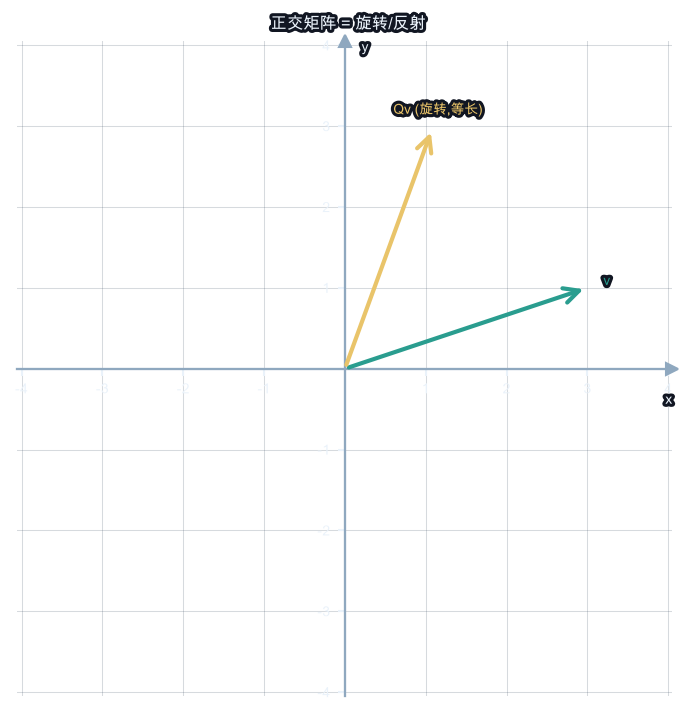

In [12]:
import numpy as np
from aurora.laviz import style, arrows2d
style()
th=0.9; R=np.array([[np.cos(th),-np.sin(th)],[np.sin(th),np.cos(th)]])
v=np.array([3.,1]); arrows2d([v, R@v], ['v','Qv (旋转,等长)'],
         title='正交矩阵 = 旋转/反射');

## 正定矩阵开场：`xᵀAx` 到底是什么，为什么要在乎它的正负？

### 从一个故事说起：弹簧的势能

设想一根弹簧，压缩或拉伸的位移是 x，储存的势能是 `E = (1/2) k x²`——位移无论正负，势能永远是正的（弹簧永远想弹回原位，不会"倒着"储存能量）。这是"能量非负"的最简单版本，只涉及一个数字 k。

现实中的振动系统往往有多个耦合的弹簧（比如桥梁的多个节点互相牵连），这时"弹性系数"不再是一个数，而是一个矩阵 K，位移也不是一个数而是一个向量 x，势能公式就变成：

`E = (1/2) xᵀ K x`

这就是**二次型**（quadratic form）——用矩阵夹住一个向量算出的一个"能量"式的数字。物理上稳定的系统（不会自己振荡到无穷大）对任何非零位移，这个能量都必须严格为正——这正是"正定矩阵"这个名字里"能量"两个字的来源，也是课程里"对任意非零向量 x，xᵀAx > 0"这条定义的直觉出处。

### 先看形状，再看数值

`xᵀAx` 看起来抽象，先把形状（shape）理清楚。设 x 是 n 维列向量，形状 `(n,)`，A 是 `(n,n)`：

- `xᵀ` 的形状是 `(1,n)`（一行 n 列）
- `xᵀ @ A`：`(1,n) @ (n,n) = (1,n)`（还是一行）
- `(xᵀA) @ x`：`(1,n) @ (n,1) = (1,1)`，也就是一个**标量**（单独一个数）

所以整条表达式从"一个向量"出发绕一圈，最后只吐出一个数——这个数就是"这个方向上的能量"。下面用具体数字走一遍。

In [13]:
import numpy as np

A = np.array([[2.0, 0.0], [0.0, 3.0]])
x = np.array([1.0, 2.0])

step1 = x @ A           # xᵀA；NumPy 的一维数组不区分"行向量"和"列向量"，形状都是 (n,)
step2 = step1 @ x       # (xᵀA) @ x，最终是一个标量
print('x =', x, ' shape:', x.shape)
print('x @ A =', step1, ' shape:', step1.shape)
print('x @ A @ x =', step2, ' ← 这是一个标量（这个方向上的"能量"）')

# 换几个方向看看是不是永远为正
print()
for x in [np.array([1., 0.]), np.array([0., 1.]), np.array([1., -1.]), np.array([-3., 2.])]:
    energy = x @ A @ x
    print(f'x={x}  ->  xᵀAx = {energy:.2f}')

x = [1. 2.]  shape: (2,)
x @ A = [2. 6.]  shape: (2,)
x @ A @ x = 14.0  ← 这是一个标量（这个方向上的"能量"）

x=[1. 0.]  ->  xᵀAx = 2.00
x=[0. 1.]  ->  xᵀAx = 3.00
x=[ 1. -1.]  ->  xᵀAx = 5.00
x=[-3.  2.]  ->  xᵀAx = 30.00


## 3. 正定矩阵（Positive Definite, PD）：Cholesky 分解的通行证

**代数定义**：对称矩阵 $A$ 称为**正定**（PD），当且仅当对所有非零向量 $x$：
$$x^\top A x > 0$$

等价条件（常用于验证）：
- 所有特征值 $\lambda_i > 0$
- Cholesky 分解 $A = L L^\top$ 存在（`np.linalg.cholesky` 不抛异常）

**半正定（PSD）**：$x^\top A x \geq 0$，允许最小特征值为 0；**不定（indefinite）**：同时有正特征值和负特征值。

**Aurora 连接**：PCA 的协方差矩阵 $C = \frac{1}{N}X^\top X$ 必须是 PSD——由 $A = M^\top M$ 构造的矩阵天然半正定。

**✏️ 小练习**：用 `M = np.random.randn(4, 3)` 构造 `A = M.T @ M`，验证它通过 Cholesky 分解（应 PD 或 PSD）。

### 追问：为什么 `MᵀM` 构造出来的矩阵"天然"半正定？

这不是巧合，是可以在几行内证明的代数事实。设 M 是任意矩阵（不必是方阵），令 `A = MᵀM`。

**第一步，A 一定对称**：`Aᵀ = (MᵀM)ᵀ = Mᵀ(Mᵀ)ᵀ = MᵀM = A`（用到"乘积转置=颠倒顺序各自转置"，以及"转置的转置=自己"，这两条都是 L12 验证过的转置定律）。这也顺带回答了"为什么 XᵀX 一定是对称矩阵"——原理完全一样，把 M 换成 X。

**第二步，A 一定半正定**：对任意向量 x，代入定义算 `xᵀAx`：

`xᵀAx = xᵀ(MᵀM)x = (xᵀMᵀ)(Mx) = (Mx)ᵀ(Mx) = |Mx|²`

中间那步只是把 `xᵀMᵀ` 拼回 `(Mx)ᵀ`（还是同一条转置定律）。而 `(Mx)ᵀ(Mx)` 正是向量 `Mx` 和自己的点积，也就是 `Mx` 长度的平方 `|Mx|²`——**长度的平方永远不会是负数**，所以 `xᵀAx ≥ 0` 对任意 x 恒成立，这正是半正定的定义。

（什么时候是"严格"正定，即 `> 0` 而不只是 `≥ 0`？当且仅当 `Mx = 0` 只有 `x = 0` 一个解时——也就是 M 的列线性无关。"线性无关"这个概念会在 L14 之后系统展开，这里先知道结论即可。）

这条证明正是"协方差矩阵天然半正定"的根本原因：协方差矩阵 `C = (1/N) XᵀX` 就是取 `M = X/√N` 代入上面的公式，所以不管数据 X 长什么样，C 永远是半正定的——这也是为什么"半正定"是"协方差矩阵合法"的必要条件（如果实际算出来的协方差矩阵不满足半正定，说明数值计算或数据本身出了问题）。协方差矩阵和 PCA 的完整应用会在后续课程展开，这里只需要记住这条"Gram 矩阵天然半正定"的代数事实。

In [14]:
import numpy as np

M = np.random.randn(4, 3)
A = M.T @ M
print('A 对称吗？', np.allclose(A, A.T))
eigvals = np.linalg.eigvalsh(A)
print('A 的特征值：', np.round(eigvals, 4), ' ← 应该全部 ≥ 0（半正定）')

A 对称吗？ True
A 的特征值： [0.6164 0.9789 3.569 ]  ← 应该全部 ≥ 0（半正定）


### Cholesky 分解到底在干什么？为什么"能分解成功"就说明正定？

**从"平方根"类比理解**：对一个正数 a，如果 a > 0，你总能找到 b 使得 `a = b²`；如果 a < 0，实数范围内根本找不到这样的 b。Cholesky 分解就是矩阵版的"开平方根"：把 A 拆成 `A = L Lᵀ`，其中 L 是一个**下三角矩阵**（对角线右上方全是 0）。可以把 L 看成"矩阵 A 的平方根"。

关键在于：**这种拆法只有 A 正定时才存在**。原因和上面 `MᵀM` 半正定的证明是一回事——如果 `A = LLᵀ`，那么对任意非零 x：

`xᵀAx = xᵀ(LLᵀ)x = (Lᵀx)ᵀ(Lᵀx) = |Lᵀx|² ≥ 0`

Cholesky 算法本身要求 L 的对角线元素非零，这保证了只要 `x ≠ 0` 就有 `Lᵀx ≠ 0`，于是这个平方长度严格大于 0，`xᵀAx > 0` 对所有非零 x 成立，A 就是正定的。反过来，`np.linalg.cholesky` 在遇到"分解不出这样的 L"（等价于要给负数开平方根）时会直接报错——**这个报错本身就是"A 不是正定"的证据**，这正是下面代码里"分解成功 ⟺ 正定"这个判据可靠的原因。

### 顺便补一下：`try / except` 是什么

如果你只学过 `print`、变量、循环，下面代码里的 `try...except` 可能是新语法。它的逻辑是"先冒险试一下，出问题就接住，不让程序崩溃"：

```python
try:
    危险的操作      # 比如 np.linalg.cholesky(A)，A 不正定时会报错
except 某种错误类型 as e:
    # 出了这种错误就跳到这里执行，程序不会崩溃退出
    补救的操作
```

具体到这节课的代码：`np.linalg.cholesky(A)` 如果 A 不正定就会抛出 `LinAlgError` 这个"异常"（error）。`except np.linalg.LinAlgError:` 这一行的意思是"专门接住这一种错误"，接住之后不再让程序中断，而是执行 `except` 块里的代码（这里是改用特征值判断半正定还是不定）。可以理解成"先假设它能分解，用特征值兜底处理分解失败的情况"。下面用一个更简单的例子（开平方根）演示同样的逻辑。

In [15]:
import math

def safe_sqrt(a):
    try:
        return math.sqrt(a)      # a < 0 时这一行会抛出 ValueError
    except ValueError as e:
        return f'⚠️ 出错但被接住了：{e}（换个方式处理，比如返回 None，而不是让程序崩溃）'

print(safe_sqrt(9))     # 正常路径，try 里的代码顺利跑完
print(safe_sqrt(-4))    # 触发 except，程序不会崩溃退出

3.0
⚠️ 出错但被接住了：math domain error（换个方式处理，比如返回 None，而不是让程序崩溃）


In [16]:
import numpy as np

# 正定判定：Cholesky 分解成功 ⟺ 正定
mats = {
    '正定': np.array([[4., 2.],[2., 3.]]),
    '半正定': np.array([[1., 1.],[1., 1.]]),
    '不定': np.array([[1., 2.],[2., 1.]]),
}
for label, A in mats.items():
    try:
        np.linalg.cholesky(A)
        tag = '✅ 正定'
    except np.linalg.LinAlgError:
        ev = np.linalg.eigvalsh(A)
        tag = '⬜ 半正定' if ev.min() >= 0 else '❌ 不定'
    print(f'{label:6s}  特征值={np.round(np.linalg.eigvalsh(A),3)}  → {tag}')


正定      特征值=[1.438 5.562]  → ✅ 正定
半正定     特征值=[0. 2.]  → ⬜ 半正定
不定      特征值=[-1.  3.]  → ❌ 不定


## 参数实验：旋转角与对称矩阵构造

**实验 1**：把 cell 11 的旋转角 `theta` 改成 `np.pi/4`、`np.pi`、`0.0`，每次运行 `is_orthogonal`——正交性与角度无关，只要是旋转矩阵（rotation matrix）结果始终为 `True`。再换成 `np.diag([2, 3])`，确认缩放矩阵不是正交矩阵。

**实验 2**：生成随机矩阵 `R = np.random.randn(3, 3)`，计算 `S = R + R.T`，验证 `np.allclose(S, S.T)` 始终为 `True`。这是从任意矩阵构造对称矩阵的标准方法——对称矩阵的特征向量矩阵正是正交矩阵，两者在特征值分解中相遇。

**别漏掉一半条件**：正交矩阵要求列向量"两两垂直"*并且*"每列长度都是 1"，两个条件缺一不可。`np.diag([2, 3])` 的两列 `[2,0]` 和 `[0,3]` 确实互相垂直（点积为 0），很多初学者验证到这一步就以为"验证通过"了——但它们的长度分别是 2 和 3，不是 1，所以 `QᵀQ` 算出来是 `[[4,0],[0,9]]` 而不是 `I`，仍然不满足正交条件。判断正交矩阵时，"垂直"和"单位长度"两个条件必须同时满足，只记住"垂直"是最容易踩的坑。

## ✏️ 参数实验：当场验证 ifft(fft(x)) == x

DFT 矩阵是酉矩阵（U⁻¹ = Uᴴ），因此逆变换等于共轭转置——这保证了 `ifft(fft(x)) == x`。现在不用等 L39，直接用 numpy 当场确认。

In [17]:
import numpy as np

# 任意实数信号
x = np.array([1.0, 2.0, -1.0, 0.5, 3.0, -0.5, 0.0, 1.5])

# FFT → 逆 FFT 应精确还原
x_roundtrip = np.fft.ifft(np.fft.fft(x)).real
assert np.allclose(x, x_roundtrip, atol=1e-12), f'最大误差 {abs(x - x_roundtrip).max():.2e}'
print(f'原始信号:  {x}')
print(f'ifft(fft): {np.round(x_roundtrip, 12)}')
print(f'最大误差:  {abs(x - x_roundtrip).max():.2e}')
print('✅ ifft(fft(x)) == x，酉矩阵性质当场验证完毕（不用等 L39）')

原始信号:  [ 1.   2.  -1.   0.5  3.  -0.5  0.   1.5]
ifft(fft): [ 1.   2.  -1.   0.5  3.  -0.5  0.   1.5]
最大误差:  2.22e-16
✅ ifft(fft(x)) == x，酉矩阵性质当场验证完毕（不用等 L39）


## 本课收束

现在可以用 `is_orthogonal(Q)` 检验任意方阵，并用 `Q.T` 直接代替 `np.linalg.inv(Q)` 求逆。
Aurora 的 `aurora.audio.transforms.dft()` 在内部使用酉矩阵乘法（旋转因子与信号做内积）；
L39 验证 `ifft(fft(x)) == x` 时直接依赖这条性质。
注：`dft_matrix(n)` 作为独立函数尚未导出——矩阵形式在 **L21** 内联完成。
下一节进入特征值分解，正交矩阵将作为特征向量矩阵再次出现。


---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


### 旁白：代码一行能出答案，为什么还要手算？

这是个好问题，值得说清楚，而不是被当成"教学仪式"糊弄过去。手算的目的不是"验证答案对不对"（这个交给代码就行），而是**逼你把矩阵乘法的每一步在脑子里过一遍**：矩阵乘法是"哪一行乘哪一列、怎么加起来"，只有亲手写出 `Qᵀ = [[0,1],[-1,0]]` 再一步步算 `Qᵀ @ Q` 的每个元素，才会真正把"矩阵乘法=逐行点积逐列"这条定义刻进直觉——这和前面"手算 `(QᵀQ)[i,j]=qᵢ·qⱼ`"是同一种训练，只是这次换成自己动笔。

推荐的做法是：**先手推，再运行代码核对**。如果推导和代码对不上，回头检查是哪一步的点积算错了，而不是直接跳过手算环节——这个"对不上再找错"的过程，才是真正建立直觉的地方。

## ✏️ 白板挑战：特殊矩阵手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：Q = [[0, -1], [1, 0]]（90° 旋转矩阵），手算 Qᵀ @ Q。  
Qᵀ = [[0, 1], [-1, 0]]，结果是 I 吗？

**问 2**：A = [[2, 1], [1, 3]]，A 是对称矩阵吗？是正定矩阵吗？  
提示：对称：Aᵀ = A；正定：所有特征值 > 0，或 Cholesky 分解成功。

**问 3**：D = [[3, 0], [0, 5]]（对角矩阵），D 是正交矩阵吗？  
提示：检验列向量模是否为 1。

**问 4**：为什么 `ifft(fft(x)) == x` 是精确的，不损失信息？  
提示：DFT 矩阵 F 是酉矩阵（F⁻¹ = F^H），属于正交族。

推导完成后运行下面格对答案。

In [18]:
# ✏️ 对答案格
import numpy as np

# 问1：Q.T @ Q = I
Q = np.array([[0., -1.], [1., 0.]])
QtQ = Q.T @ Q
assert np.allclose(QtQ, np.eye(2), atol=1e-12)
print(f"Q1 ✅  Q.T @ Q = {QtQ}  （单位阵，Q 是正交的）")

# 问2：对称 + 正定
A = np.array([[2., 1.], [1., 3.]])
sym = np.allclose(A, A.T, atol=1e-12)
try:
    np.linalg.cholesky(A)
    pd = True
except np.linalg.LinAlgError:
    pd = False
assert sym and pd, f"sym={sym}, pd={pd}"
eigvals = np.linalg.eigvalsh(A)
print(f"Q2 ✅  [[2,1],[1,3]] 对称={sym}，正定={pd}，特征值={np.round(eigvals,3)}")

# 问3：对角矩阵 D 不是正交矩阵（列模≠1）
D = np.array([[3., 0.], [0., 5.]])
try:
    is_orth = is_orthogonal(D)
    assert not is_orth, f"D 不应是正交矩阵，is_orthogonal 返回了 {is_orth}"
    print(f"Q3 ✅  diag(3,5) 不是正交矩阵（列模={np.linalg.norm(D[:,0])},{np.linalg.norm(D[:,1])}≠1）")
except (NotImplementedError, TypeError):
    print("⬜ Q3：请先实现 is_orthogonal()，再运行对答案格")

# 问4：DFT 精确可逆
x = np.array([1., 2., -1., 0.5])
reconstructed = np.fft.ifft(np.fft.fft(x))
assert np.allclose(reconstructed.real, x, atol=1e-12)
print(f"Q4 ✅  ifft(fft(x)) 误差={np.max(np.abs(reconstructed.real - x)):.2e} → 精确（DFT 矩阵为酉矩阵）")
print("\n🎉 特殊矩阵白板挑战通过！三类特殊矩阵的本质已内化。")

Q1 ✅  Q.T @ Q = [[1. 0.]
 [0. 1.]]  （单位阵，Q 是正交的）
Q2 ✅  [[2,1],[1,3]] 对称=True，正定=True，特征值=[1.382 3.618]
⬜ Q3：请先实现 is_orthogonal()，再运行对答案格
Q4 ✅  ifft(fft(x)) 误差=0.00e+00 → 精确（DFT 矩阵为酉矩阵）

🎉 特殊矩阵白板挑战通过！三类特殊矩阵的本质已内化。


In [ ]:
# ✏️ 本课自评
l13_review = {
    "is_orthogonal_implemented":  None,  # is_orthogonal 实现并通过断言？True/False
    "orthogonal_inverse_trick":   None,  # 理解 Q⁻¹=Qᵀ 的含义？True/False
    "symmetric_pd_distinction":   None,  # 能区分对称矩阵和正定矩阵？True/False
    "fft_unitarity_understood":   None,  # 理解 ifft(fft(x))=x 源于正交性？True/False
    "whiteboard_passed":          None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l13_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l13_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L13 全部通关！进入 L14：特征值与 SVD')

---

→ **下一课**　[L14 · 特征值与 SVD](L14_eigen_svd.ipynb)

> 下节课将学习 **特征值与 SVD**：找到矩阵偏爱的方向，用 SVD 打开低秩世界。